In [1]:
from __future__ import annotations

import logging
from pathlib import Path
from tqdm import tqdm

from src.utils import pmf_utils
import pandas as pd
import matplotlib.pyplot as plt
import importlib, src.ddm.ddm
importlib.reload(src.ddm.ddm)

import numpy as np
import torch
import pickle

from config import dir_config

from src.ddm.utils import build_stimulus, prepare_data, load_model

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


In [2]:
# change directory to project root
import os
cwd = Path.cwd()
if cwd.name == "notebooks":
    os.chdir(cwd.parent)

from scripts.ddm.ddm_fitting import DDMModel

In [3]:
processed_dir = Path(dir_config.data.processed)
ddm_dir = processed_dir / 'ddm'
# ddm_dir = processed_dir / 'ddm_5a9ce9d'

session_metadata = pd.read_csv(processed_dir / "sessions_metadata.csv")
behavior_df = pd.read_csv(ddm_dir / "behavior_data.csv")

best_model = "leak-1_tc-1"

In [4]:
model_dir = ddm_dir / best_model

In [5]:
def plot_ddm_fit(data, sim, title="DDM Fit"):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 4))

    cohs_sorted = sorted(data["signed_coherence"].unique())

    def summarize(df):
        p_upper = []
        mean_rt_upper, sem_rt_upper = [], []
        mean_rt_lower, sem_rt_lower = [], []
        for c in cohs_sorted:
            subset = df[df["signed_coherence"] == c].dropna(subset=["rt", "choice"])
            p_upper.append((subset["choice"] == 1).mean() if len(subset) > 0 else np.nan)
            upper = subset[subset["choice"] == 1]["rt"]
            lower = subset[subset["choice"] == 0]["rt"]
            mean_rt_upper.append(upper.mean() if len(upper) > 0 else np.nan)
            sem_rt_upper.append(upper.sem() if len(upper) > 0 else np.nan)
            mean_rt_lower.append(lower.mean() if len(lower) > 0 else np.nan)
            sem_rt_lower.append(lower.sem() if len(lower) > 0 else np.nan)
        return np.array(p_upper), np.array(mean_rt_upper), np.array(sem_rt_upper), np.array(mean_rt_lower), np.array(sem_rt_lower)

    def get_subset(df, outcome):
        if outcome == "correct":
            return df[
                ((df["choice"] == 1) & (df["signed_coherence"] > 0)) |
                ((df["choice"] == 0) & (df["signed_coherence"] < 0)) |
                (df["signed_coherence"] == 0)
            ]
        elif outcome == "incorrect":
            return df[
                ((df["choice"] == 0) & (df["signed_coherence"] > 0)) |
                ((df["choice"] == 1) & (df["signed_coherence"] < 0)) |
                (df["signed_coherence"] == 0)
            ]
        else:
            raise ValueError("Outcome must be 'correct' or 'incorrect'")

    def summarize2(df, outcome):
        df = get_subset(df, outcome)
        mean_rt, sem_rt = [], []
        for c in cohs_sorted:
            subset = df[df["signed_coherence"] == c].dropna(subset=["rt", "choice"])
            mean_rt.append(subset["rt"].mean() if len(subset) > 0 else np.nan)
            sem_rt.append(subset["rt"].sem() if len(subset) > 0 else np.nan)
        return np.array(mean_rt), np.array(sem_rt)

    def plot_chromo_sem(x, y, yerr, color, label, ax):
        ax.plot(x, y, "o-", color=color, label=label)
        ax.fill_between(x, y - yerr, y + yerr, color=color, alpha=0.2)

    d_p_upper, d_mean_rt_upper, d_sem_rt_upper, d_mean_rt_lower, d_sem_rt_lower = summarize(data)
    s_p_upper, s_mean_rt_upper, s_sem_rt_upper, s_mean_rt_lower, s_sem_rt_lower = summarize(sim)

    # Psychometric function
    ax1.plot(cohs_sorted, d_p_upper, "o-", color="steelblue", label="Data")
    ax1.plot(cohs_sorted, s_p_upper, "-", color="tomato", label="Model")
    ax1.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
    ax1.axvline(0.0, color="gray", linestyle="--", linewidth=0.8)
    ax1.set(xlabel="Coherence", ylabel="P(upper boundary)", title="Psychometric Function", ylim=(0, 1))

    d_mean_rt_correct, d_sem_rt_correct = summarize2(data, "correct")
    d_mean_rt_incorrect, d_sem_rt_incorrect = summarize2(data, "incorrect")
    s_mean_rt_correct, s_sem_rt_correct = summarize2(sim, "correct")
    s_mean_rt_incorrect, s_sem_rt_incorrect = summarize2(sim, "incorrect")

    plot_chromo_sem(cohs_sorted, d_mean_rt_correct, d_sem_rt_correct, color="steelblue", label="Data", ax=ax2)
    plot_chromo_sem(cohs_sorted, s_mean_rt_correct, s_sem_rt_correct, color="tomato", label="Model", ax=ax2)
    plot_chromo_sem(cohs_sorted, d_mean_rt_incorrect, d_sem_rt_incorrect, color="steelblue", label="Data", ax=ax3)
    plot_chromo_sem(cohs_sorted, s_mean_rt_incorrect, s_sem_rt_incorrect, color="tomato", label="Model", ax=ax3)

    ax2.set(xlabel="Coherence", ylabel="Mean RT (s)", title="Chronometric - Correct Trials")
    ax3.set(xlabel="Coherence", ylabel="Mean RT (s)", title="Chronometric - Incorrect Trials")

    y_min = min(ax2.get_ylim()[0], ax3.get_ylim()[0])
    y_max = max(ax2.get_ylim()[1], ax3.get_ylim()[1])
    ax2.set_ylim(y_min, y_max)
    ax3.set_ylim(y_min, y_max)

    ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    for ax in [ax1, ax2, ax3]:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.suptitle(title)
    plt.tight_layout()
    return fig


In [6]:
def get_simulated_data(model_struct, behavior_df):
    session_data = prepare_data(
        behavior_df,
        session_id=model_struct['job']['session_id'],
        prior_block=int(model_struct['job']['prior_block']),
    )
    stimulus = build_stimulus(session_data)
    sim_data = model_struct['model'].simulate(
        stimulus=stimulus,
        params=model_struct['results']['parameters'],
        n_reps=1
    )
    return session_data, pd.DataFrame(sim_data)


In [7]:
fitted_params = []
s_data, d_data = [], []

plot_individual_fits = False

for idx, model_path in tqdm(enumerate(model_dir.rglob("*.pkl")), desc=f"Processing models in {model_dir.name}", unit="file"):
    try:
        model_struct = load_model(model_path)
        parameters = model_struct['results']['parameters']
        session_id = model_struct['job']['session_id']
        prior_block = model_struct['job']['prior_block']
        fitted_params.append({
            "session_id": session_id,
            "prior_block": prior_block,
            **parameters
        })
    except Exception as e:
        print(f"Error loading {model_path}: {e}")



    d_session_data, s_session_data = get_simulated_data(model_struct, behavior_df)
    # add session_id and prior_block to both dataframes for later analysis
    d_session_data["session_id"] = session_id
    d_session_data["prior_block"] = prior_block
    s_session_data["session_id"] = session_id
    s_session_data["prior_block"] = prior_block
    d_data.append(d_session_data)
    s_data.append(s_session_data)

    if plot_individual_fits:
        fig = plot_ddm_fit(
            data=d_session_data,
            sim=s_session_data,
            title=f"DDM Fit: {session_id}_prior_block_{prior_block}"
        )

d_data = pd.concat(d_data, ignore_index=True)
s_data = pd.concat(s_data, ignore_index=True)
fitted_params = pd.DataFrame(fitted_params)

Processing models in leak-1_tc-1: 90file [00:59,  1.51file/s]


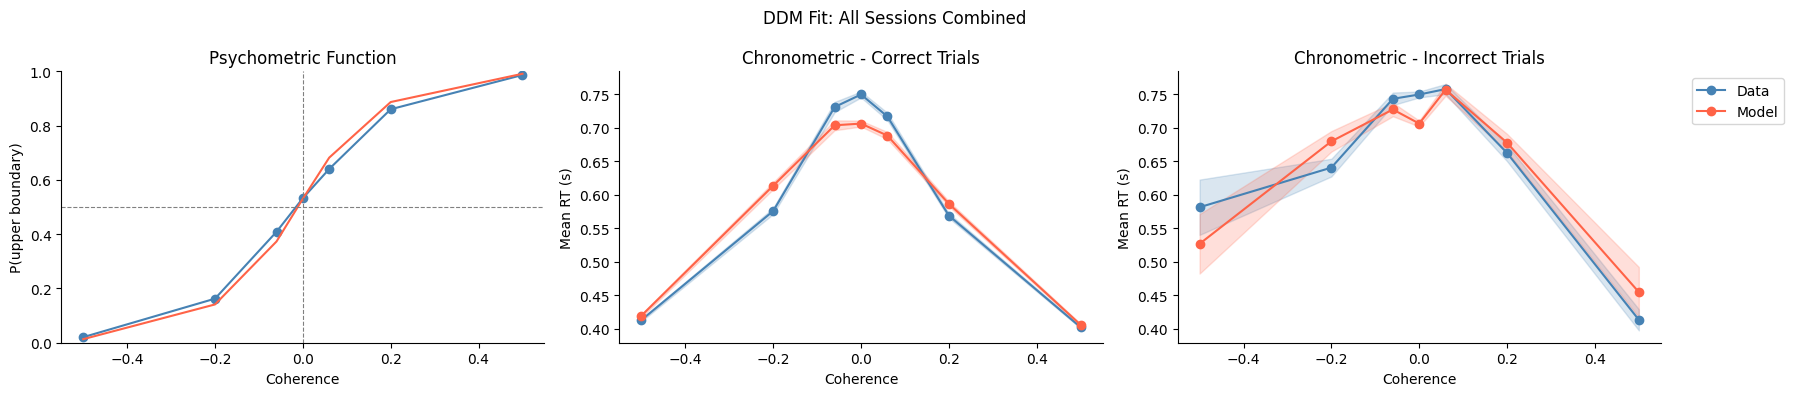

In [8]:
plot_ddm_fit(data=d_data, sim=s_data, title=f"DDM Fit: All Sessions Combined");

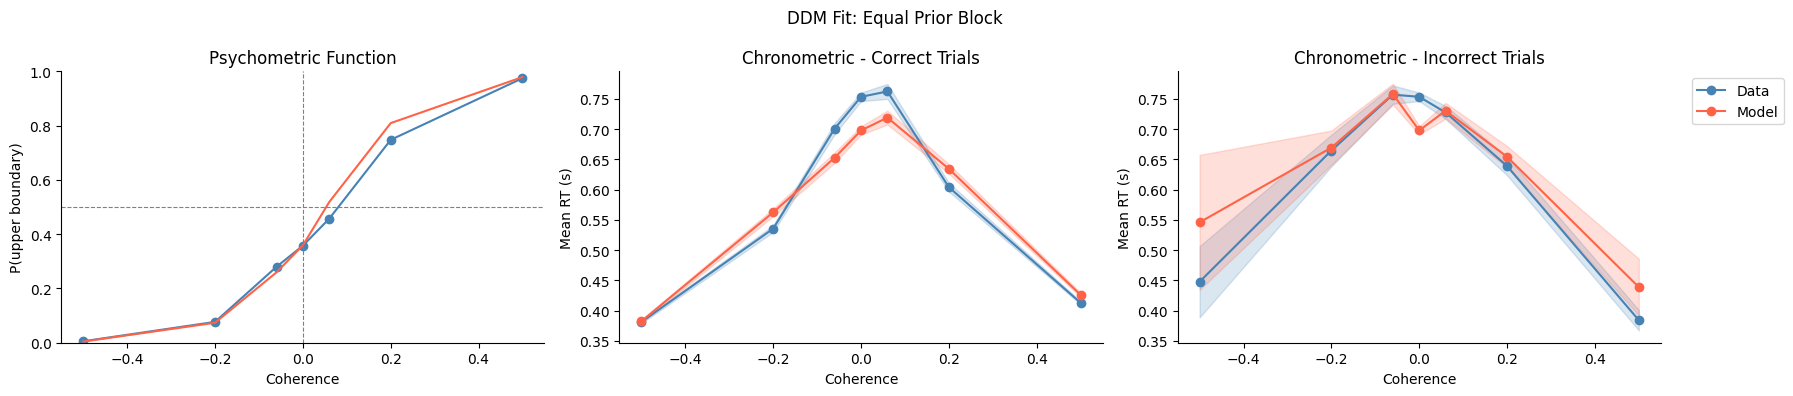

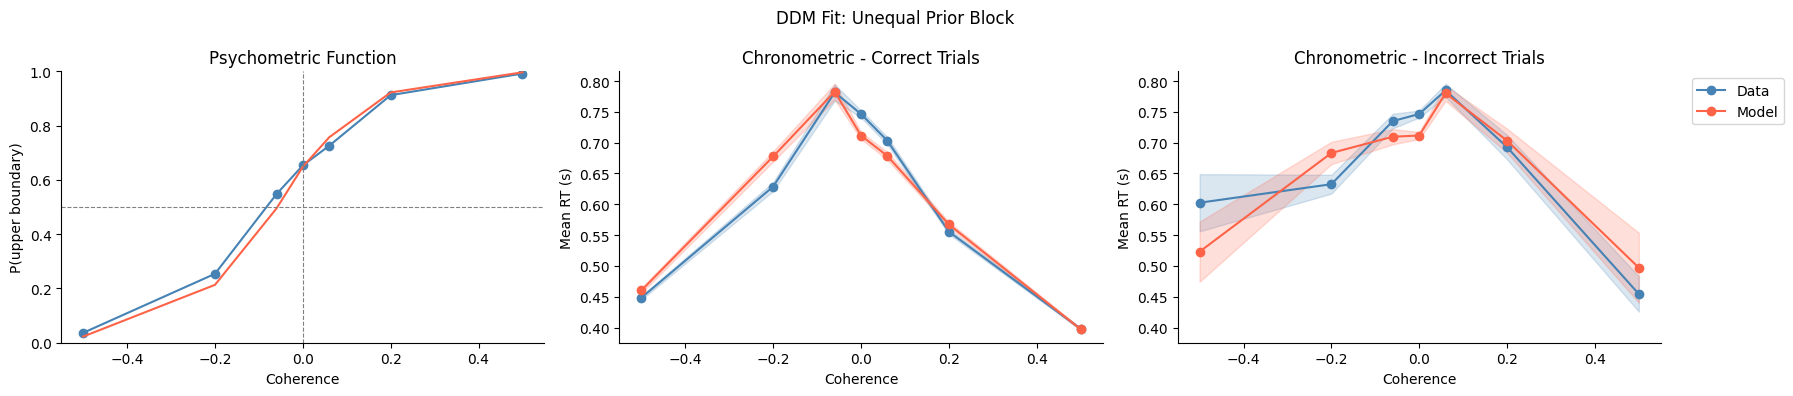

In [9]:
# equal_block_data
s_equal = s_data[s_data["prior_block"] == 0]
d_equal = d_data[d_data["prior_block"] == 0]
plot_ddm_fit(data=d_equal, sim=s_equal, title=f"DDM Fit: Equal Prior Block");
s_unequal = s_data[s_data["prior_block"] == 1]
d_unequal = d_data[d_data["prior_block"] == 1]
plot_ddm_fit(data=d_unequal, sim=s_unequal, title=f"DDM Fit: Unequal Prior Block");

In [10]:
equal_block = fitted_params.groupby("session_id").apply(lambda df: df[df["prior_block"] == 0].iloc[0] if len(df) == 2 else None)
unequal_block = fitted_params.groupby("session_id").apply(lambda df: df[df["prior_block"] == 1].iloc[0] if len(df) == 2 else None)
equal_block = equal_block.dropna().reset_index(drop=True)
unequal_block = unequal_block.dropna().reset_index(drop=True)

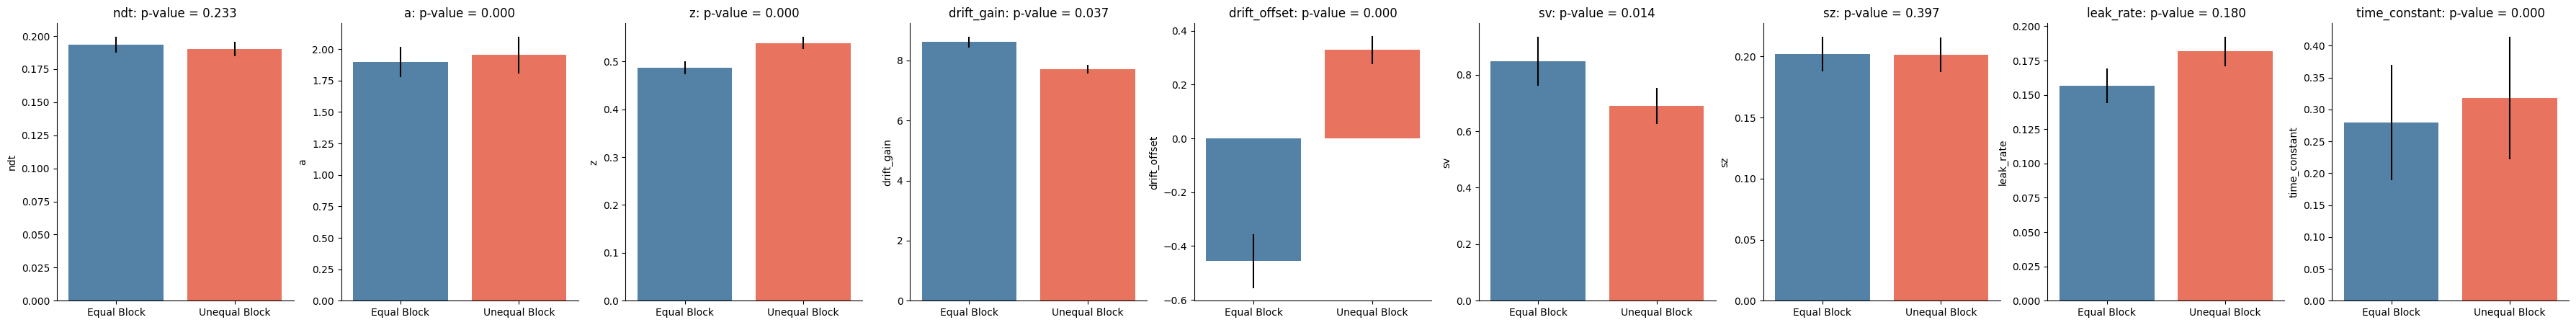

In [11]:
# for each column in fitted_params except session_id and prior_block, plot equal vs unequal block values; plot bar graph with error bars for each parameter comparing equal vs unequal block; plot scatter plot with equal block on x-axis and unequal block on y-axis for each parameter; calculate correlation between equal and unequal block values for each parameter
import seaborn as sns
from scipy.stats import pearsonr


ignore_cols = ["session_id", "prior_block", "dt", "variance"]

correlations = {}

fig, axs = plt.subplots(1, len(fitted_params.columns) - len(ignore_cols), figsize=(5 * (len(fitted_params.columns) - len(ignore_cols)), 5))

for idx, col in enumerate(fitted_params.columns):
    if col in ignore_cols:
        continue

    corr, p_value = pearsonr(equal_block[col], unequal_block[col])
    # Bar graph with error bars
    means = [equal_block[col].mean(), unequal_block[col].mean()]
    sems = [equal_block[col].sem(), unequal_block[col].sem()]

    idx=idx - len(ignore_cols)  # adjust index for axes
    sns.barplot(x=["Equal Block", "Unequal Block"], y=means, yerr=sems, palette=["steelblue", "tomato"], ax=axs[idx])
    axs[idx].set_ylabel(col)
    axs[idx].set_title(f"{col}: p-value = {p_value:.3f}")

    axs[idx].spines['top'].set_visible(False)
    axs[idx].spines['right'].set_visible(False)